In [1]:
import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from pathlib import Path

##########################################################
# Initialize parameters  
##########################################################

filename = "../data/packet-warm_hotchan1_150cycles_20s_7tiles_2025_12_17.hdf5"

asic_dir = "../asic_configs/asic_configs_packet-warm_hotchan1_150cycles_20s_7tiles_2025_12_27_PST/" 
     
# tiles tested in this filename or the subset of tiles on which you wish to check tally 
tiles = [1,2,3,4,5,6,7]
chip_serial_number_list = ['', '4k02056', '4k03591', '4k01892', '4k02219', '4k02371', '4k04834', '4k00101' ]

# Setting verbose = True will print out various pieces of chip-level or packet-level information 
verbose = True

# identify chips with hot channels to enable graphs before and after disabling the channel
#problem_chips = [[], [50, 60], [81], [], [], [160]]

# the following values are just being initialized to zero       
nenabled_chips = 0
ig = 1 #this script can only run 1 io_group (and 1 tile) at a time
files = []
ndisabled_channels = [0 for chp in range(256)]

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
# create an array of file names from the directory passed to this function
def get_files(directory):

    global nenabled_chips
    
    asic_config_files = []  # the set of files in the given directory
    f_number = 0
    found_files = False

    with os.scandir(directory) as entries:

        # order the directory files by names
        file_entries = sorted(entries, key=lambda entry: entry.name)
        file_items = [entry.name for entry in file_entries]
        
        f_number = len(file_items) # number of files in the directory
        nenabled_chips = f_number

        for i in range(1,f_number):
            filename = directory + file_items[i]
            asic_config_files.append(filename)
            found_files = True

        if found_files == False:
            print(f'\n##### Did not find files in directory {directory} #####\n')
    
    return asic_config_files

In [3]:
def get_io_channels(tile):

    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
        ]
    
    return io_ch_per_tile[tile]


In [4]:
def get_data(filename, tile, ig):
    
    global data_pkts, npkts_mode, npkts_mode_chan, ndisabled_channels
    global chip_serial_number, problem_chips
    
    data_chips, ndata_by_chip_list, ndata_by_channel_list, npkts = [], [], [], 0
    ndata_by_chip    = [0 for chip in range(256)]
    ndata_by_channel = [[0 for chan in range(64)] for chip in range(256)]
    unique_chips  = []
    debug_count = 0

    print(f'\n######### Checking Tile {tile} ########') 
    
    # read packet data from initialized file name
    f = h5py.File(filename, 'r')
    packets = f['packets'][:]
    
    # create arrays of data packets
    data_mask     = f['packets'][:]['packet_type']  == 1
    data_pkts     = packets[data_mask]
    
    # mask for the chosen tile
    io_channel_ids = get_io_channels(tile)

    tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
    data_pkts = data_pkts[tile_mask]

    if len(data_pkts) ==0:
        print(f'There are no data packets for tile {tile}')
        return
    
#########################################################
# identify hot channels
##########################################################
    
    data_chips = data_pkts['chip_id'][:]

    unique_chips = list(dict.fromkeys(data_chips))
    
    nzero_pkts_chip = [0 for c in range(256)]
    
    # determine the most common number of packets by chip and by channel
    for chip in range(11,171):

        # mask for chip
        chip_mask = data_pkts['chip_id'] == chip
        chip_pkts = data_pkts[chip_mask]

        chip_ioch  = chip_pkts['io_channel'][:]
        chip_chans = chip_pkts['channel_id'][:]
        unique_iochs = list(dict.fromkeys(chip_ioch))
               
        # create list used later to determine mode of # pkts per chip
        ndata_by_chip[chip] = len(chip_pkts)
        ndata_by_chip_list.append(ndata_by_chip[chip])

        unique_channels = list(dict.fromkeys(chip_chans))
        
        # create list used to later determine mode of # pkts per channel
        for chan in range(64):
            
            # mask for channel
            chan_mask = chip_pkts['channel_id'] == chan
            chan_pkts = chip_pkts[chan_mask]

            # count the # of packets by channel (exclude zeros)
            ndata_by_channel[chip][chan] = len(chan_pkts)
            if ndata_by_channel[chip][chan] > 0:         
                ndata_by_channel_list.append(ndata_by_channel[chip][chan])
            else:
                nzero_pkts_chip[chip] +=1

    # determine the most common # of packets. In pedestal mode this should be relatively consistent
    npkts_mode = mode(ndata_by_chip_list)
    npkts_mode_chan = mode(ndata_by_channel_list)

    print(f'\tStats: Most common # of packets in a chip {npkts_mode}, Most common # of packets in a channel {npkts_mode_chan}\n')

    # look for chips and channels with high counts relative to the modes 
    for chip in range(11,171):
                    
        # check to see if the # of channels with no packets exceeds the number of disabled channels
        n_unexpected_zero_pkts = nzero_pkts_chip[chip] - ndisabled_channels[chip]
            
        if n_unexpected_zero_pkts > 0:
            print(f'\nTile {tile}: Chip {chip} had {ndisabled_channels[chip]} disabled channels. {n_unexpected_zero_pkts} additional channels had no packets')
            
        # account for disabled channels when determining how many packets to expect from a chip
        nchannels = 64 - ndisabled_channels[chip]

        npkts_expected = nchannels * npkts_mode_chan
        
        # look for chips with unusually high data counts
        #if (ndata_by_chip[chip] > npkts_expected *10) or chip in problem_chips[tile]:
        if ndata_by_chip[chip] > npkts_expected * 10:

            # hot channels impact the datwords in their chips. create arrays to understand the geographic nature
            # of this phenomina
            mean_adc_list, stdev_adc_list, chan_list = [],[],[]
            
            # mask for the high-count chip
            noisy_chip_mask = data_pkts['chip_id']==chip
            noisy_chip_pkts = data_pkts[noisy_chip_mask]
            noisy_channels = noisy_chip_pkts['channel_id'][:]
            noisy_chip_datawords = noisy_chip_pkts['dataword'][:]   

            noisy_chip_percent = 100 * len(noisy_chip_pkts) / npkts_mode

            print(f'\nChip {chip} has {len(noisy_chip_pkts)} pkts, or {noisy_chip_percent:.0f}% of the expected # of packets {npkts_mode}\n')
            
            # determine the most common # of packets in this chip's channels, and flag hot channels
            for chan in range(64):

                # mask for channel
                chan_mask = noisy_chip_pkts['channel_id']==chan  
                chan_pkts = noisy_chip_pkts[chan_mask]

                ndata_by_channel[chip][chan] = len(chan_pkts)
                chan_adc = chan_pkts['dataword']
                chan_list.append(chan)

                # remove zero datawords
                non_zero_chan_adc = chan_adc[chan_adc != 0]

                # calculate non-zero mean and stdev for datawords
                if len(non_zero_chan_adc) > 1:               
                    mean_adc = mean(non_zero_chan_adc.tolist())
                    mean_adc_list.append(mean_adc)
                    
                    std_adc = stdev(non_zero_chan_adc.tolist())
                    stdev_adc_list.append(std_adc)

                elif len(non_zero_chan_adc) ==0: 
                    mean_adc_list.append(0)
                    
                    stdev_adc_list.append(0)
                
                else:
                    mean_adc = mean(non_zero_chan_adc.tolist())
                    mean_adc_list.append(mean_adc)                    

                    stdev_adc_list.append(0)
                           
                # count number of packets per channel
                if ndata_by_channel[chip][chan]>0:
                    ndata_by_channel_list.append(ndata_by_channel[chip][chan])

                    # hot channels have many orders of magnitude more packets than those in pedestal mode
                    if ndata_by_channel[chip][chan] > npkts_mode_chan * 10:
                        print(f'\tChannel {chip}-{chan} has {ndata_by_channel[chip][chan]} packets which is {100 * ndata_by_channel[chip][chan] / npkts_mode_chan:.0f}% of typical channel')

            if npkts_mode_chan == 0 and verbose:
                print(f"Problem with chip {chip}: the mode of pkt counts per channel = 0")
                continue
                    
            fig, axis = plt.subplots(3,1, figsize=(5, 16))

            axis[0].hist(noisy_channels, bins=64)
            axis[0].set_title(f'Chip {chip} on Tile {tile}: Packet Count per Channel\nPacket Count {100*ndata_by_chip[chip]/npkts_mode:.0f}% of typical chip (expected Chan Count {npkts_mode_chan})\nBenchtop test of v3a Tile #{chip_serial_number}')
            axis[0].set_xlabel(f'Channel ID')
            #axis[0].set_xlim(0,63)
            axis[0].set_yscale('log')
            axis[0].set_ylabel(f'# of Data Packets')
            plt.show 

            axis[1].bar(chan_list, mean_adc_list)
            axis[1].set_title(f'Chip {chip} on Tile {tile}: Mean ADC per Channel')
            axis[1].set_xlabel(f'Channel ID')
            #axis[1].set_xlim(0,63)
            axis[1].set_ylabel(f'Mean ADC Dataword')
            plt.show     

            axis[2].bar(chan_list, stdev_adc_list)
            axis[2].set_title(f'Chip {chip} on Tile {tile}: Stdev ADC per Channel')
            axis[2].set_xlabel(f'Channel ID')
            #axis[2].set_xlim(0,63)
            axis[2].set_ylabel(f'Stdev ADC Dataword')
            plt.show         
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.hist(data_chips, bins=256)
    ax.set_title(f'Tile {tile} Packet Count per Chip\nChip Count Mode {npkts_mode}, Channel Count Mode {npkts_mode_chan}\nBenchtop test of v3a Tile {tile} ({chip_serial_number})')
    ax.set_xlabel(f'Chip ID')
    ax.set_yscale('log')
    ax.set_ylabel(f'Data Packet Count')
    plt.show 
    
    return 

In [5]:
def count_disabled_per_chip(files):

    global ndisabled_channels, verbose
    
    for file in files:

        config={}
        with open(file, 'r') as f: config=json.load(f)

        ndisabled = sum( config['channel_mask'] )
        chip = config['chip_id']
        ndisabled_channels[chip] = ndisabled
        
        if ndisabled > 0 and verbose:
            print(f'Chip {chip} has {ndisabled} disabled channels (as noted in asic file {file})')

    return


######### Checking Tile 1 ########
	Stats: Most common # of packets in a chip 1079, Most common # of packets in a channel 3


Tile 1: Chip 34 had 0 disabled channels. 2 additional channels had no packets

Tile 1: Chip 38 had 0 disabled channels. 1 additional channels had no packets

Tile 1: Chip 39 had 0 disabled channels. 1 additional channels had no packets

Tile 1: Chip 50 had 0 disabled channels. 2 additional channels had no packets

Chip 50 has 2300433 pkts, or 213200% of the expected # of packets 1079

	Channel 50-12 has 2241983 packets which is 74732767% of typical channel
	Channel 50-13 has 1335 packets which is 44500% of typical channel
	Channel 50-14 has 56866 packets which is 1895533% of typical channel

Tile 1: Chip 60 had 0 disabled channels. 5 additional channels had no packets

Chip 60 has 2288108 pkts, or 212058% of the expected # of packets 1079

	Channel 60-26 has 59960 packets which is 1998667% of typical channel
	Channel 60-28 has 2227893 packets which is 74263100%

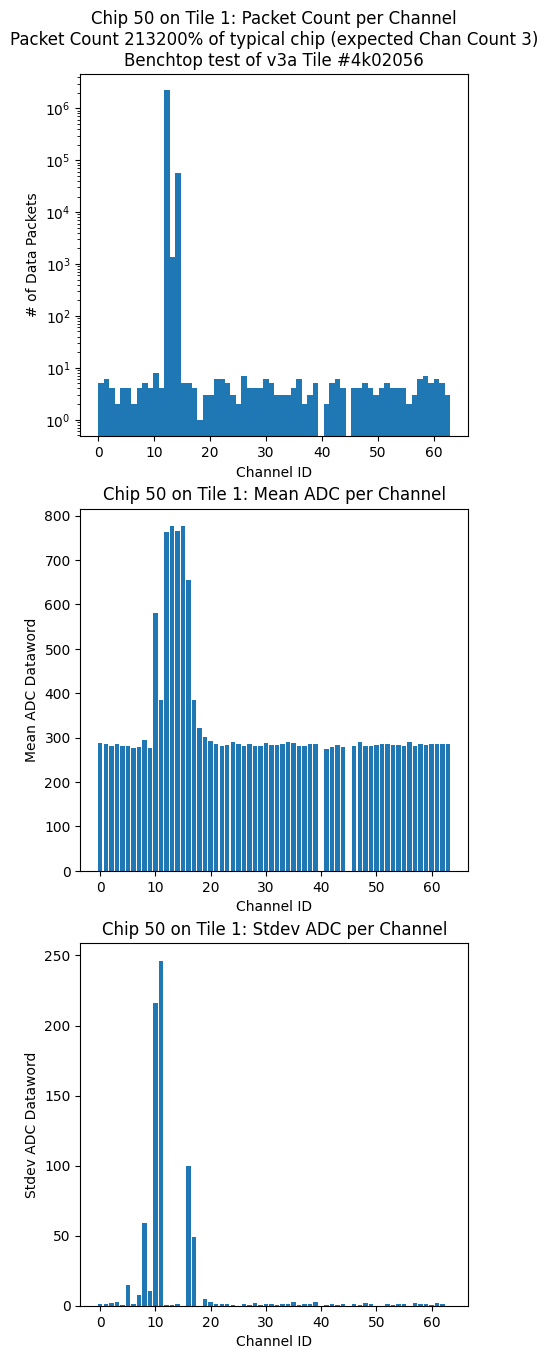

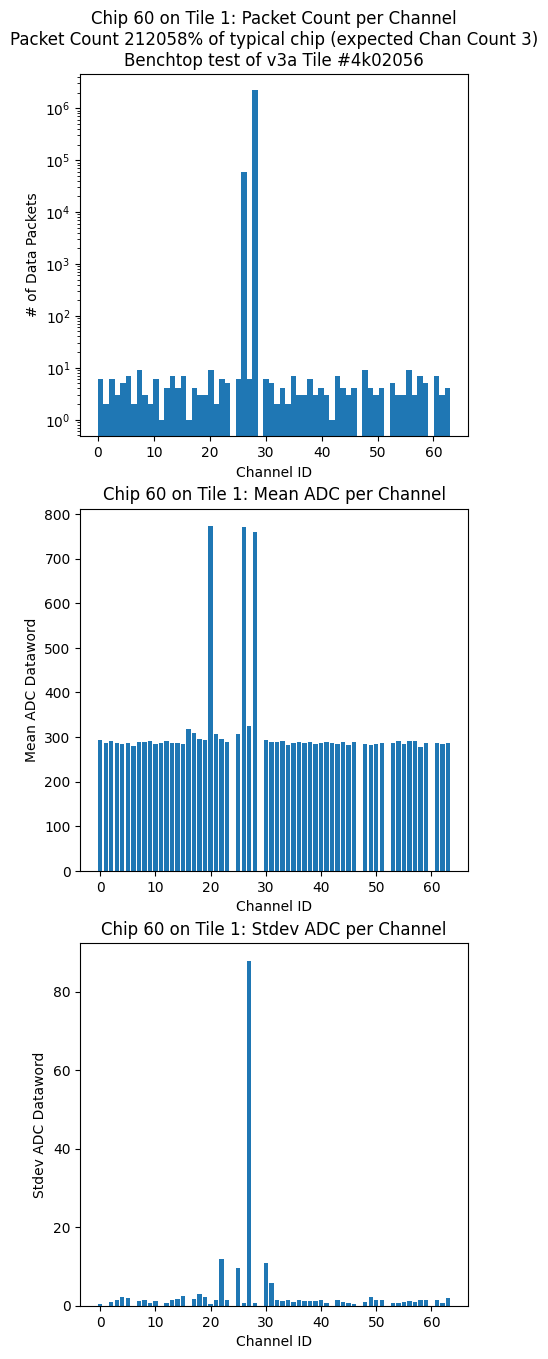

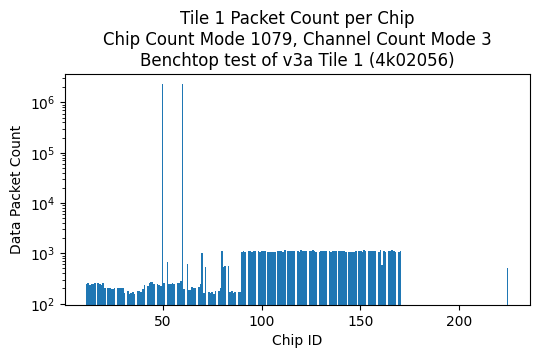

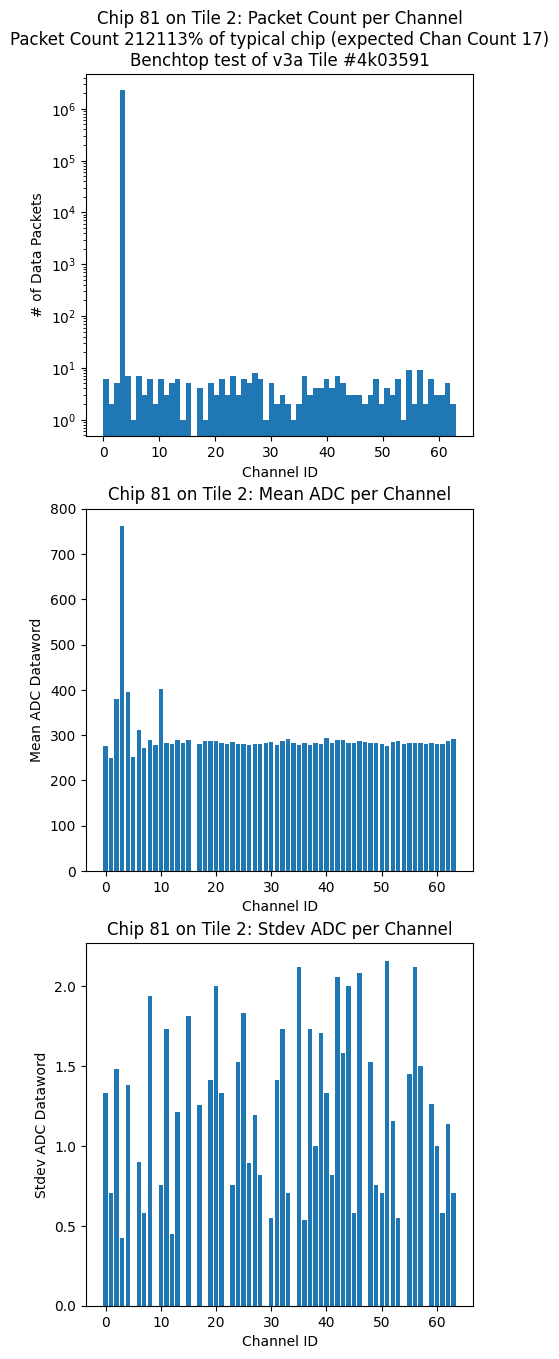

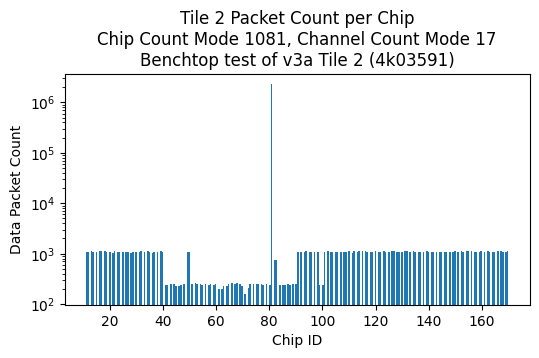

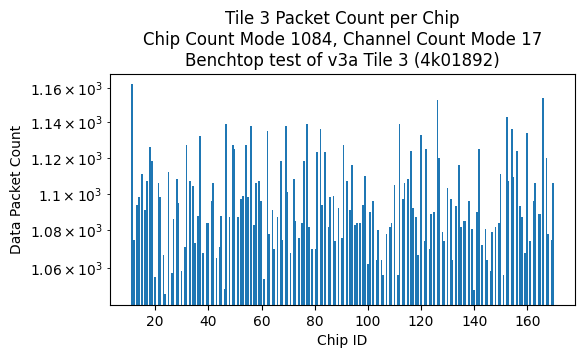

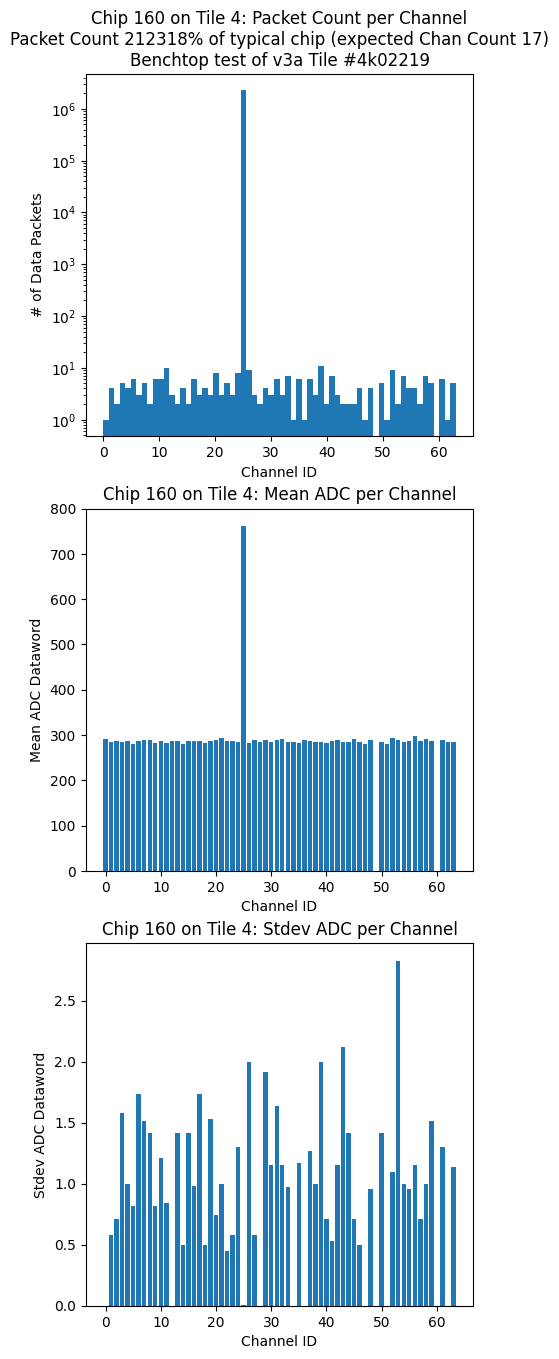

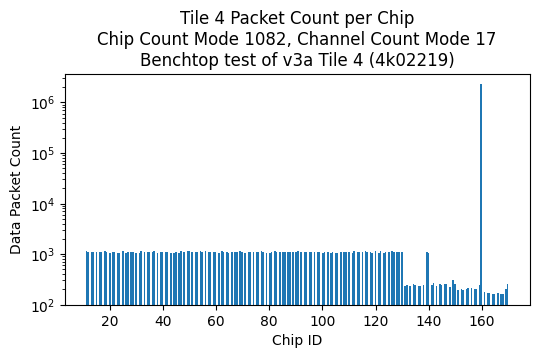

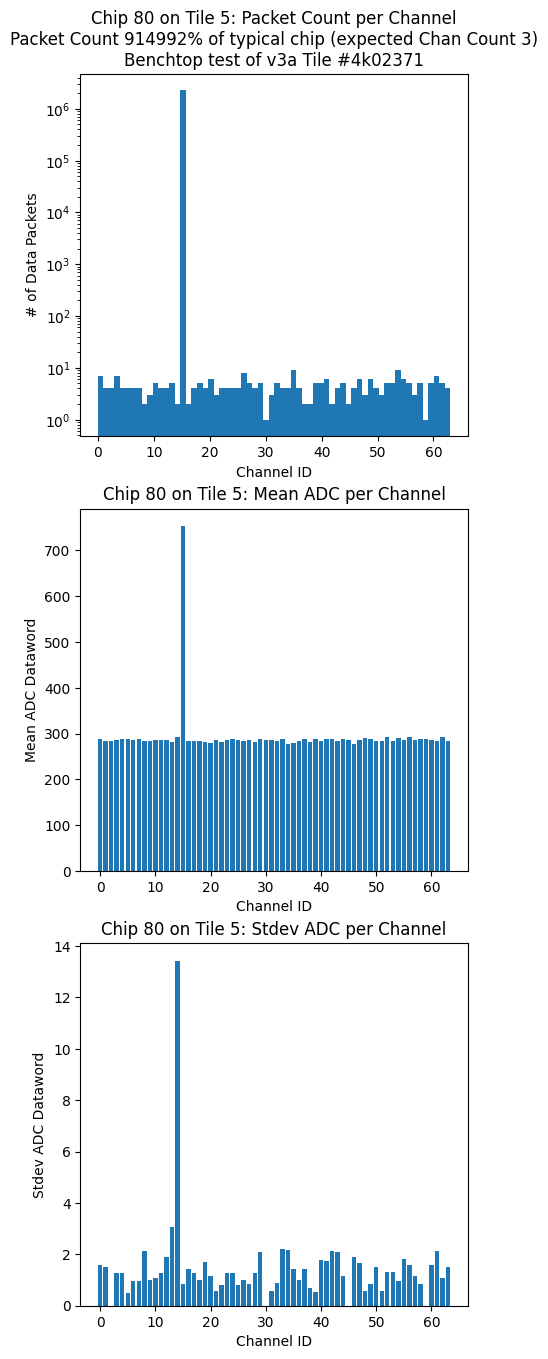

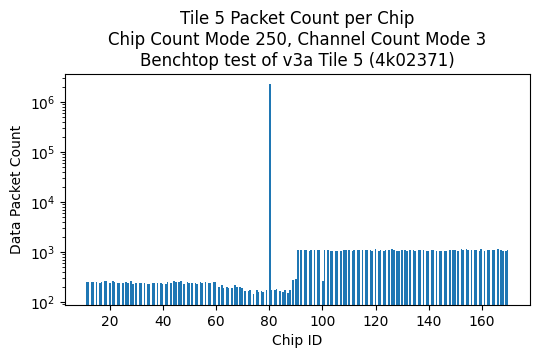

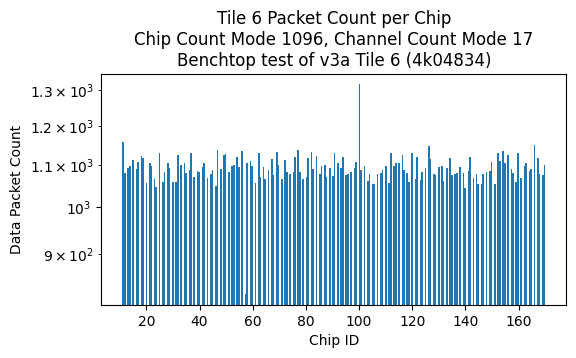

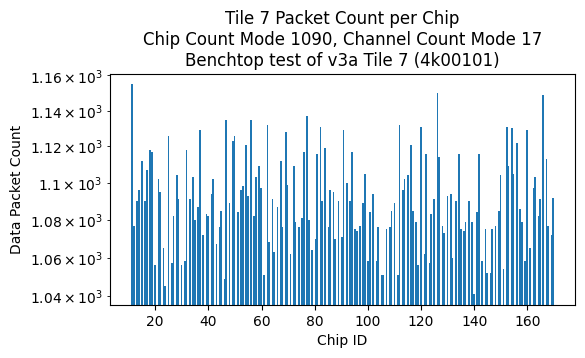

In [6]:
####################
# main
####################

# create file list of asic_config json files
files = get_files(asic_dir)

# count disabled channels per chip from the asic_config files
count_disabled_per_chip(files)

# get packets from pedestal run data file and check for various attributes
for tile in tiles:
    chip_serial_number = chip_serial_number_list[tile]
    get_data(filename, tile, ig)
